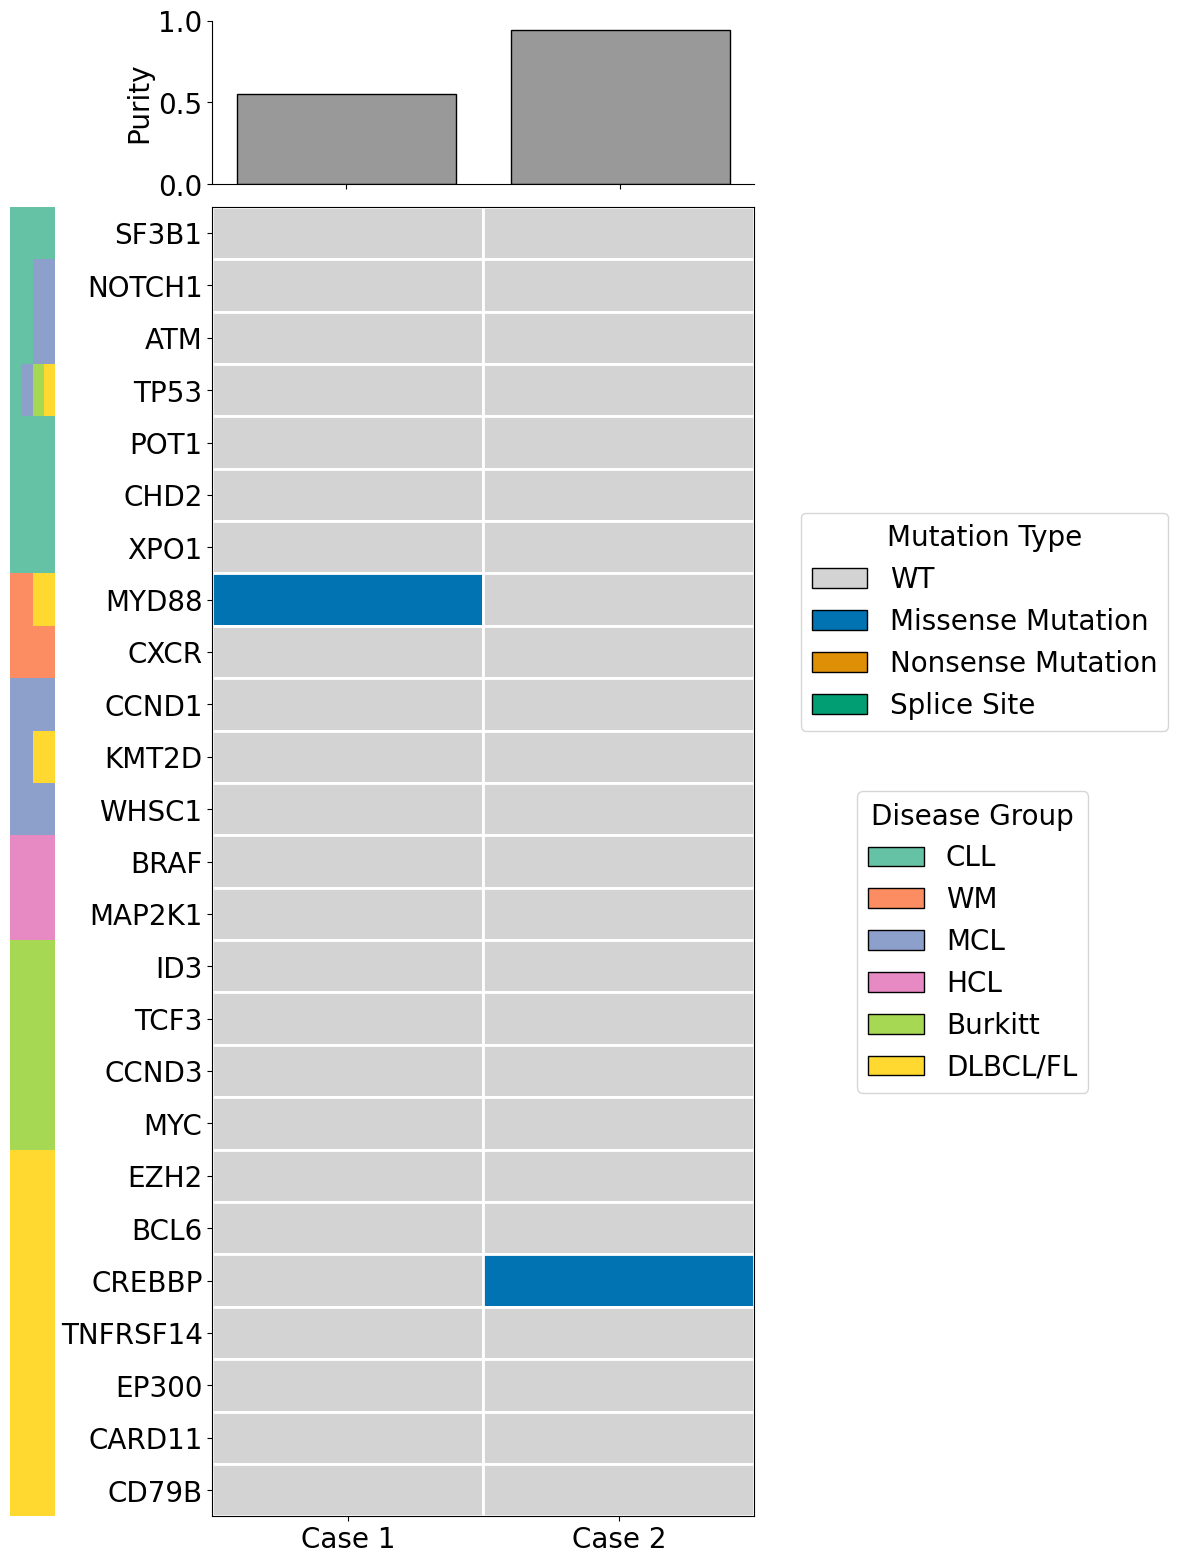

In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# 1. Load safe intermediate data mapping matrix
df = pd.read_csv("../data/PROMISE_WGS_MAF_matrix.csv", sep=",", index_col='Hugo_Symbol')

cll_genes = ['SF3B1', 'NOTCH1', 'ATM', 'TP53', 'POT1', 'CHD2', 'XPO1']
wm_genes = ['MYD88', 'CXCR']
mcl_genes = ['CCND1', 'TP53', 'ATM', 'NOTCH1', 'KMT2D', 'WHSC1']
hcl_genes = ['BRAF', 'MAP2K1']
burkitt_genes = ['ID3', 'TCF3', 'CCND3', 'TP53', 'MYC']
dlbcl_fl_genes = ['EZH2', 'BCL6', 'CREBBP', 'KMT2D', 'TNFRSF14', 'EP300', 'CARD11', 'MYD88', 'CD79B', 'TP53']

gene_to_groups = defaultdict(list)
for g in cll_genes: gene_to_groups[g].append("CLL")
for g in wm_genes: gene_to_groups[g].append("WM")
for g in mcl_genes: gene_to_groups[g].append("MCL")
for g in hcl_genes: gene_to_groups[g].append("HCL")
for g in burkitt_genes: gene_to_groups[g].append("Burkitt")
for g in dlbcl_fl_genes: gene_to_groups[g].append("DLBCL/FL")

group_palette = sns.color_palette("Set2", n_colors=6)
group_colors = {
    "CLL": group_palette[0], "WM": group_palette[1], "MCL": group_palette[2],
    "HCL": group_palette[3], "Burkitt": group_palette[4], "DLBCL/FL": group_palette[5]
}

# Safe decoupled purity metric profiles
purity_dict = {"case1": 0.55, "case2": 0.94}
purity_df = pd.DataFrame.from_dict(purity_dict, orient='index', columns=["Purity"])

mutation_palette = sns.color_palette("colorblind", n_colors=4)
mutation_colors = {
    "WT": "lightgrey",
    "Missense_Mutation": mutation_palette[0],
    "Nonsense_Mutation": mutation_palette[1],
    "Splice_Site": mutation_palette[2]
}

fig = plt.figure(figsize=(8, 16))
gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[0.5, 6], height_ratios=[0.5, 4])
plt.rcParams.update({'font.size': 20})

# --- Top Subplot: Purity Profile Bars ---
ax_purity = fig.add_subplot(gs[0, 1])
ax_purity.bar(purity_df.index, purity_df["Purity"], color="#999999", edgecolor="black", width=0.8, align='center')
ax_purity.set_ylabel("Purity", fontsize=20)
ax_purity.set_ylim(0, 1)
ax_purity.spines["top"].set_visible(False)
ax_purity.spines["right"].set_visible(False)
ax_purity.set_xticklabels([])

# --- Side Subplot: Gene Group Color Strip Bars ---
ax_group_color = fig.add_subplot(gs[1, 0])
for i, gene in enumerate(df.index):
    groups = gene_to_groups.get(gene, [])
    n_groups = len(groups)
    for k, group in enumerate(groups):
        color = group_colors.get(group, "lightgrey")
        stripe_width = 1.0 / n_groups
        x_left = k * stripe_width
        rect = plt.Rectangle((x_left, i), stripe_width, 1, facecolor=color, linewidth=0)
        ax_group_color.add_patch(rect)

ax_group_color.set_xlim(0, 1)
ax_group_color.set_ylim(0, len(df.index))
ax_group_color.invert_yaxis()
ax_group_color.axis("off")

# --- Main Subplot: Oncoprint Heatmap Grid ---
ax_onco = fig.add_subplot(gs[1, 1], sharey=ax_group_color)
for i, gene in enumerate(df.index):
    for j, sample in enumerate(df.columns):
        mutation = df.loc[gene, sample]
        color = mutation_colors.get(mutation, "lightgrey")
        rect = plt.Rectangle((j - 0.5, i), 1, 1, facecolor=color, edgecolor="white", linewidth=2)
        ax_onco.add_patch(rect)

ax_onco.set_xticks(np.arange(len(df.columns)))
ax_onco.set_xticklabels(['Case 1', 'Case 2'], fontsize=20)
ax_onco.set_yticks(np.arange(len(df.index)) + 0.5)
ax_onco.set_yticklabels(df.index, fontsize=20)
ax_onco.set_xlim(-0.5, len(df.columns) - 0.5)
ax_onco.set_ylim(0, len(df.index))
ax_onco.invert_yaxis()

# --- Legends Setup ---
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=mutation_colors[mut], edgecolor="black") for mut in mutation_colors]
legend_labels = [" ".join(mut.split("_")) for mut in mutation_colors.keys()]
fig.legend(handles, legend_labels, title="Mutation Type", loc="center right", fontsize=20, bbox_to_anchor=(1.5, 0.6))

group_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=group_colors[group], edgecolor="black") for group in group_colors.keys()]
group_labels = list(group_colors.keys())
fig.legend(group_handles, group_labels, title="Disease Group", loc="center right", fontsize=20, bbox_to_anchor=(1.4, 0.4))

plt.tight_layout(pad=1.0, h_pad=0.2, w_pad=0.2)

plt.savefig(f'../00.Figures/PROMISE_oncoprint.pdf', format='pdf', bbox_inches='tight')
plt.show()

